# Laboratorio de IA Ética: Sesgos y Explicabilidad

**Bootcamp Python – PY4**  
**Módulo:** Machine Learning Avanzado y Feature Engineering  
**Sesión 1 de 3:** Entrenamiento del modelo base  

---

En este laboratorio vamos a trabajar con un caso muy común en la industria: un banco que usa un modelo de Machine Learning para decidir si aprueba o no un crédito. El objetivo del laboratorio completo es aprender a **explicar** las decisiones de un modelo complejo, y a **evaluar si esas decisiones son éticamente aceptables**.


## 1. Preparar el entorno de trabajo

Antes de tocar cualquier dato, instalamos las librerías que vamos a necesitar durante todo el laboratorio (no solo hoy). Usamos:

- `xgboost`: el modelo que vamos a entrenar.
- `shap` y `lime`: las librerías de interpretabilidad que usaremos despues.
- `scikit-learn`: para el split de datos y las métricas de evaluación.
- `joblib`: para guardar el modelo entrenado en un archivo y poder reutilizarlo en la próxima sesión.

In [ ]:
!pip install xgboost shap lime scikit-learn joblib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Ahora importamos las librerías que vamos a usar en esta sesión.

In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

import xgboost as xgb
import joblib
import matplotlib.pyplot as plt

## 2. Cargar el dataset

Vamos a usar el **German Credit Data**, un dataset real y muy usado en la industria financiera. Contiene 1000 clientes de un banco alemán, con información sobre su situación financiera y personal, y una etiqueta que indica si el crédito otorgado resultó en buen o mal riesgo (`credit_risk`).

Elegimos este dataset por dos razones:

- Es exactamente el escenario de "crédito aprobado vs. denegado" que vamos a necesitar para el análisis local con SHAP y LIME en la Sesión 2.
- Contiene algunas variables interesantes desde el punto de vista ético (por ejemplo, una columna que mezcla sexo y estado civil en un solo valor). No vamos a discutir esto todavía, pero lo vamos a tener presente: en la Sesión 3 vamos a volver a este tema con más detalle.

El dataset está disponible públicamente en GitHub, así que lo cargamos directamente desde ahí, sin necesidad de descargar nada manualmente.

In [ ]:
url = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/Module_02_machine_learning_and_feature_engineering/datasets/GermanCredit.csv"
df = pd.read_csv(url)

df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


## 3. Exploración inicial

Antes de entrenar cualquier modelo, siempre conviene mirar el dataset con calma: cuántas filas y columnas tiene, qué tipo de dato es cada columna, si hay valores nulos, y cómo se distribuye la variable que queremos predecir (`credit_risk`).

In [ ]:
print("Filas y columnas:", df.shape)
df.info()

Filas y columnas: (1000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status                   1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   amount                   1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence        1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing     

In [ ]:
print("Valores nulos por columna:")
print(df.isnull().sum().sum())

print()
print("Distribución de la variable objetivo (credit_risk):")
print(df["credit_risk"].value_counts())
print(df["credit_risk"].value_counts(normalize=True).round(2))

Valores nulos por columna:
0

Distribución de la variable objetivo (credit_risk):
credit_risk
1    700
0    300
Name: count, dtype: int64
credit_risk
1    0.7
0    0.3
Name: proportion, dtype: float64


Vas a notar que la clase `1` (buen crédito) representa el 70% de los casos, mientras que la clase `0` (mal crédito) es solo el 30%. Esto se conoce como un dataset **desbalanceado**, y es la razón por la cual más adelante no vamos a mirar solo el `accuracy` del modelo, sino también el `F1-score`.

## 4. Diccionario de variables

Antes de seguir, es importante entender qué significa cada columna. Esta es una referencia rápida:

| Columna | Significado |
|---|---|
| `status` | Estado de la cuenta corriente del cliente |
| `duration` | Duración del crédito, en meses |
| `credit_history` | Historial crediticio previo |
| `purpose` | Propósito del crédito (auto, electrodomésticos, etc.) |
| `amount` | Monto del crédito |
| `savings` | Monto en la cuenta de ahorros |
| `employment_duration` | Años en el empleo actual |
| `installment_rate` | Cuota como porcentaje del ingreso disponible |
| `personal_status_sex` | Sexo y estado civil combinados en una sola variable (ojo con esto: lo retomaremos en la Sesión 3) |
| `other_debtors` | Si existen codeudores o garantes |
| `present_residence` | Años en la residencia actual |
| `property` | Tipo de propiedad que posee |
| `age` | Edad del cliente |
| `other_installment_plans` | Otros créditos o planes de pago vigentes |
| `housing` | Tipo de vivienda (propia, alquilada, etc.) |
| `number_credits` | Número de créditos existentes en el banco |
| `job` | Tipo de empleo |
| `people_liable` | Personas a cargo del cliente |
| `telephone` | Si el cliente tiene teléfono registrado |
| `foreign_worker` | Si el cliente es trabajador extranjero (variable sensible, también la retomaremos en la Sesión 3) |
| `credit_risk` | Variable objetivo: `1` = buen crédito, `0` = mal crédito |

No es necesario memorizar esta tabla, pero sí vale la pena volver a ella cuando estemos interpretando los resultados de SHAP y LIME más adelante.

### ¿De dónde sale la etiqueta `credit_risk`?

Este dataset viene de registros reales de un banco alemán (Hofmann, 1994, UCI Machine Learning Repository). La etiqueta `credit_risk` no la asignó un algoritmo: refleja cómo resultó cada crédito en la práctica, según los registros del banco (pagó bien vs. tuvo problemas de pago).

En otras palabras, el "ground truth" es el juicio histórico del banco, no una verdad objetiva. Si esas decisiones tenían sesgos, el modelo los aprende igual, como si fueran parte del patrón.

In [ ]:
# Define la variable objetivo
target = "credit_risk"

# Separa las variables predictoras (X) y la variable objetivo (y)
X = df.drop(columns=[target])
y = df[target]


In [ ]:
pd.DataFrame(X[['status', 'savings']]).head()

,status,savings
0,... < 100 DM,unknown/no savings account
1,0 <= ... < 200 DM,... < 100 DM
2,no checking account,... < 100 DM
3,... < 100 DM,... < 100 DM
4,... < 100 DM,... < 100 DM


In [ ]:
print(X["status"].unique())

['... < 100 DM' '0 <= ... < 200 DM' 'no checking account'
 '... >= 200 DM / salary for at least 1 year']


## 5. Preprocesamiento: preparar las variables para el modelo

XGBoost, como la mayoría de los modelos de Machine Learning, necesita que todas las variables sean numéricas. Nuestro dataset tiene muchas columnas categóricas (texto), como `purpose` o `housing`, así que necesitamos convertirlas.

La técnica que usamos se llama **one-hot encoding**: por cada categoría de una variable, se crea una nueva columna con valores `True`/`False` (o 1/0). Usamos `drop_first=True` para evitar generar columnas redundantes (si ya sabemos que las demás categorías son `False`, la última se puede deducir).

Después de codificar, hacemos una pequeña limpieza de los nombres de columnas: `pd.get_dummies` genera nombres con símbolos como `<`, `>=` o `,`, y XGBoost no acepta esos caracteres en los nombres de las columnas.

### Limpiar los nombres de las columnas

Cuando aplicamos `pd.get_dummies`, pandas genera automáticamente los nombres de las nuevas columnas combinando el nombre original de la variable con cada una de sus categorías. El problema es que muchas de esas categorías en el German Credit Data contienen símbolos como `<`, `>=`, `,` o `...` (por ejemplo: `status_... < 200 DM`), y XGBoost **no acepta** ese tipo de caracteres especiales en los nombres de las columnas.

Por eso necesitamos una función que limpie y estandarice esos nombres antes de entrenar el modelo.

Para esto usamos `re.sub()`, una función de la librería `re` (expresiones regulares) que sirve para **buscar un patrón de texto y reemplazarlo por otra cosa**. Su forma general es:

```python
re.sub(patron, reemplazo, texto)
```

En nuestra función, la usamos dos veces:

- `re.sub(r"[\[\]<>=,/:]", "", col)`: busca cualquiera de esos caracteres especiales (`[`, `]`, `<`, `>`, `=`, `,`, `/`, `:`) y los elimina, reemplazándolos por nada (`""`).
- `re.sub(r"[\s\.\-]+", "_", col.strip())`: busca uno o más espacios, puntos o guiones seguidos, y los reemplaza por un solo guion bajo (`_`), para que el nombre quede parejo.

El resto de la función se encarga de dejar el nombre bien prolijo:

- Elimina las secuencias de puntos suspensivos (`...`) que aparecen en algunas categorías.
- Colapsa los guiones bajos repetidos en uno solo, y quita los que hayan quedado al principio o al final.
- Convierte todo a minúsculas, para mantener un formato consistente en todo el dataset.

Al final, aplicamos esta función a **todos** los nombres de columnas de `X_enc`, para que el modelo pueda entrenarse sin errores.

In [ ]:
# Convierte las variables categóricas en variables dummy (one-hot encoding)
# drop_first=True evita la multicolinealidad eliminando una categoría de referencia
X_enc = pd.get_dummies(X, drop_first=True)

# Función para limpiar y estandarizar los nombres de las columnas
def limpiar_nombre_columna(col):
    col = col.replace("...", "")                  # Elimina secuencias de puntos
    col = re.sub(r"[\[\]<>=,/:]", "", col)        # Elimina caracteres especiales
    col = re.sub(r"[\s\.\-]+", "_", col.strip())  # Reemplaza espacios, puntos y guiones por "_"
    col = re.sub(r"_+", "_", col).strip("_")      # Elimina guiones bajos repetidos
    return col.lower()                            # Convierte el nombre a minúsculas

# Aplica la limpieza a todos los nombres de columnas
X_enc.columns = [limpiar_nombre_columna(c) for c in X_enc.columns]
print("Shape antes de codificar:", X.shape)
print("Shape despues de codificar:", X_enc.shape)
X_enc.head()

Shape antes de codificar: (1000, 20)
Shape despues de codificar: (1000, 48)


,duration,amount,installment_rate,present_residence,age,number_credits,people_liable,status_200_dm_salary_for_at_least_1_year,status_0_200_dm,status_no_checking_account,...,property_unknownno_property,other_installment_plans_none,other_installment_plans_stores,housing_own,housing_rent,job_skilled_employeeofficial,job_unemployedunskilled_non_resident,job_unskilled_resident,telephone_yes,foreign_worker_yes
0,6,1169,4,4,67,2,1,False,False,False,...,False,True,False,True,False,True,False,False,True,True
1,48,5951,2,2,22,1,1,False,True,False,...,False,True,False,True,False,True,False,False,False,True
2,12,2096,2,3,49,1,2,False,False,True,...,False,True,False,True,False,False,False,True,False,True
3,42,7882,2,4,45,1,2,False,False,False,...,False,True,False,False,False,True,False,False,False,True
4,24,4870,3,4,53,2,2,False,False,False,...,True,True,False,False,False,True,False,False,False,True


## 6. Separar en entrenamiento y prueba (train / test split)

Separamos el dataset en un conjunto de entrenamiento (para que el modelo aprenda) y uno de prueba (para evaluar qué tan bien generaliza a datos que nunca vio). Usamos `stratify=y` para asegurarnos de que la proporción 70/30 de buen/mal crédito se mantenga igual en ambos conjuntos.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y,
    test_size=0.2,
    random_state=42,
    stratify=y # "stratify=y" mantiene la misma proporción de clases en ambos el train y test set
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (800, 48)
Prueba: (200, 48)


## 7. Entrenar el modelo base: XGBoost

XGBoost es un modelo de tipo **ensamble de árboles**: entrena muchos árboles de decisión pequeños de forma secuencial, donde cada nuevo árbol intenta corregir los errores del anterior (esto se llama *gradient boosting*). Es uno de los modelos más usados en la industria para datos tabulares, porque suele lograr muy buen rendimiento.

El problema es que, precisamente por estar compuesto de cientos de árboles combinados, es muy difícil mirarlo y entender "a simple vista" por qué toma cada decisión. Es un modelo preciso, pero se comporta como una **caja negra**. Ese es justamente el problema que vamos a resolver en la Sesión 2 con SHAP y LIME.

Por ahora, lo entrenamos con una configuración simple.

In [ ]:
# Configura el modelo XGBoost para clasificación
model = xgb.XGBClassifier(
    n_estimators=200,      # Número de árboles que se construirán
    max_depth=4,           # Profundidad máxima de cada árbol
    learning_rate=0.1,     # Tasa de aprendizaje: controla cuánto aporta cada árbol nuevo
    eval_metric="logloss", # Métrica utilizada durante el entrenamiento
    random_state=42        # Garantiza resultados reproducibles
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

>**¿Qué es Log Loss?**
>
>**Log Loss** (o *logarithmic loss*) es una métrica utilizada en problemas de clasificación que evalúa qué tan buenas son las **probabilidades predichas** por el modelo.   
>
>En general, **cuanto menor sea el Log Loss, mejor es el modelo**.

## 8. Evaluar el rendimiento del modelo

Con el modelo ya entrenado, generamos predicciones sobre el conjunto de prueba y las comparamos con los valores reales.

Miramos dos métricas:

- **Accuracy:** porcentaje de predicciones correctas en total. Ojo: como el dataset está desbalanceado (70/30), un modelo que simplemente prediga "buen crédito" siempre tendría un accuracy artificialmente alto.
- **F1-score:** combina precisión y recall en una sola métrica, y es más confiable cuando las clases no están balanceadas.

También revisamos la matriz de confusión, que nos muestra específicamente en qué tipo de errores está cayendo el modelo (por ejemplo, si aprueba créditos que en realidad eran de alto riesgo).

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("F1-score:", round(f1_score(y_test, y_pred), 3))
print()
#print(classification_report(y_test, y_pred, target_names=["mal_credito", "buen_credito"]))

Accuracy: 0.745
F1-score: 0.825



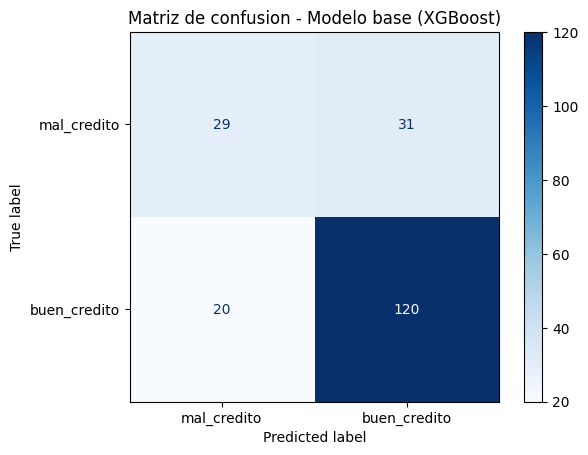

In [ ]:
# Muestra la matriz de confusión del modelo sobre el conjunto de prueba
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["mal_credito", "buen_credito"],  # Etiquetas de las clases
    cmap="Blues"                                     # Paleta de colores
)

plt.title("Matriz de confusion - Modelo base (XGBoost)")
plt.show()

Hay poquitos observaciones en la matriz de confusión. Es porque la matriz solo muestra el conjunto de prueba, no el conjunto de datos completo.

## 9. Guardar el modelo y los datos para la próxima sesión

Para no tener que repetir todo este proceso en la Sesión 2, guardamos:

- El modelo entrenado (`model.pkl`).
- Los conjuntos de entrenamiento y prueba (`data_split.pkl`), que vamos a necesitar para calcular los valores de SHAP y para elegir los casos que vamos a analizar con LIME.

De esta forma, la próxima sesión puede arrancar directo en la parte de interpretabilidad.

In [ ]:
joblib.dump(model, "model.pkl")
joblib.dump((X_train, X_test, y_train, y_test), "data_split.pkl")

print("Modelo y datos guardados correctamente.")

Modelo y datos guardados correctamente.


## 10. Cierre y reflexión

- ¿El accuracy y el F1-score que obtuvimos te parecen suficientemente buenos para usar este modelo en un banco real?
- Si tuvieras que aprobar o rechazar un crédito basándote solo en estas métricas, ¿confiarías completamente en la decisión del modelo?
- ¿Qué preguntas te quedan sobre **cómo** el modelo llega a cada decisión, más allá de qué tan seguido acierta?

Esa última pregunta es exactamente el punto de partida de la próxima sesión: vamos a abrir la caja negra de este mismo modelo usando **SHAP** y **LIME**, para entender qué variables influyen más en sus decisiones, tanto a nivel general como en casos individuales.